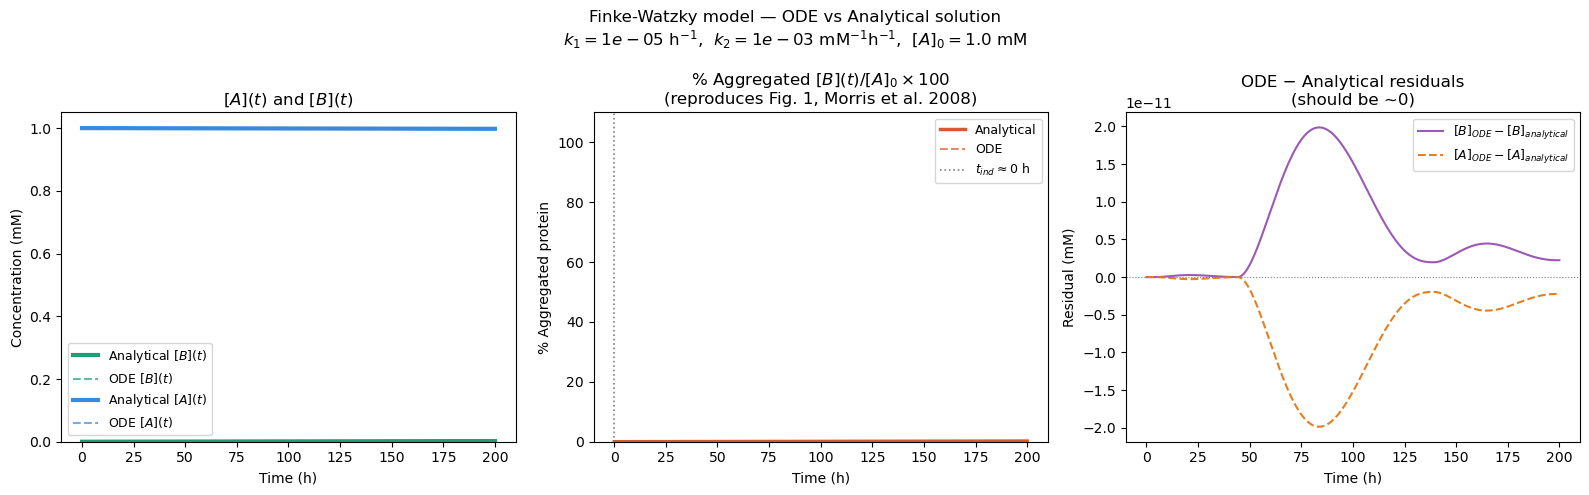

Max absolute residual |ODE - Analytical|: 1.99e-11 mM
Relative error: 1.99e-09 %


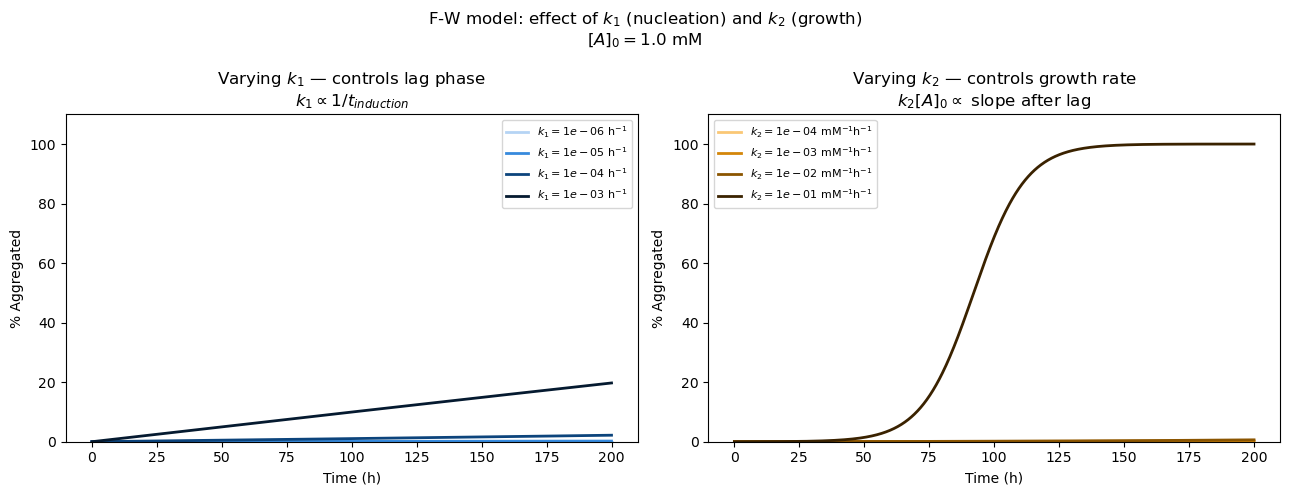


VALIDATION TABLE: ODE vs Analytical at selected time points
Parameters: k1=1e-05, k2=1e-03, A0=1.0
   t (h) |  [B] Analyt. |      [B] ODE |     Residual |   Rel. err %
----------------------------------------------------------------------
       0 |     0.000000 |     0.000000 |     0.00e+00 |     0.00e+00
      20 |     0.000202 |     0.000202 |     2.71e-13 |     2.71e-11
      50 |     0.000513 |     0.000513 |     1.63e-12 |     1.63e-10
      80 |     0.000833 |     0.000833 |     1.96e-11 |     1.96e-09
     100 |     0.001051 |     0.001051 |     1.52e-11 |     1.52e-09
     150 |     0.001617 |     0.001617 |     3.14e-12 |     3.14e-10
     200 |     0.002211 |     0.002211 |     2.23e-12 |     2.23e-10

Conclusion: Max relative error = 1.99e-09 %  →  ODE agrees with analytical solution ✓


In [3]:
"""
Finke-Watzky 2-Step Model — ODE + Analytical Solution
======================================================
Week 1, Question 5:
  Implement the ODE of the Finke-Watzky model.
  Verify agreement with the analytical solution.

Model (Morris et al., Biochemistry 2008):
  Reactions:
    A  -k1->  B          (slow continuous nucleation)
    A + B -k2-> 2B       (fast autocatalytic surface growth)

  ODE (eq. 1):
    d[A]/dt = -k1*[A] - k2*[A]*[B]

  Conservation:
    [A] + [B] = [A]0   →   [B] = [A]0 - [A]

  Analytical solution (eq. 2):
    [A](t) = (k1/k2 + [A]0) / (1 + (k1/(k2*[A]0)) * exp((k1 + k2*[A]0)*t))

  Useful relationships (Figure 1 of paper):
    k1  ∝  1 / t_induction    (nucleation rate → lag time)
    k2*[A]0  ∝  slope after induction period  (growth rate)
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


# ══════════════════════════════════════════════════════════════
# 1. ANALYTICAL SOLUTION  (eq. 2 & 3 from Morris et al. 2008)
# ══════════════════════════════════════════════════════════════

def fw_analytical(t, k1, k2, A0):
    """
    Analytical solution for [A](t) and [B](t).

    Parameters
    ----------
    t  : array  - time points
    k1 : float  - nucleation rate constant     (units: 1/time)
    k2 : float  - autocatalytic growth rate    (units: 1/(conc·time))
    A0 : float  - initial monomer concentration

    Returns
    -------
    A  : array  - [A](t)  monomer remaining
    B  : array  - [B](t)  aggregate formed  (= A0 - A)
    """
    numerator   = k1/k2 + A0
    denominator = 1.0 + (k1 / (k2 * A0)) * np.exp((k1 + k2 * A0) * t)
    A = numerator / denominator
    B = A0 - A
    return A, B


# ══════════════════════════════════════════════════════════════
# 2. ODE SOLUTION  (eq. 1 via scipy solve_ivp)
# ══════════════════════════════════════════════════════════════

def fw_ode(t, k1, k2, A0, n_points=500):
    """
    Numerical solution of the F-W ODE:
      d[A]/dt = -k1*[A] - k2*[A]*[B]
      [B] = A0 - [A]

    Parameters
    ----------
    Same as fw_analytical.

    Returns
    -------
    t_sol : array  - time points
    A_sol : array  - [A](t)
    B_sol : array  - [B](t)
    """
    def rhs(t, y):
        A = y[0]
        B = A0 - A          # conservation law
        dA = -k1*A - k2*A*B
        return [dA]

    t_span = (t[0], t[-1])
    t_eval = t

    sol = solve_ivp(
        rhs,
        t_span,
        [A0],               # initial condition: [A](0) = A0, [B](0) = 0
        t_eval=t_eval,
        method='RK45',
        rtol=1e-10,
        atol=1e-12
    )

    A_sol = sol.y[0]
    B_sol = A0 - A_sol
    return sol.t, A_sol, B_sol


# ══════════════════════════════════════════════════════════════
# FIGURE 1 — ODE vs Analytical (baseline parameters)
#   Reproduce Figure 1 from Morris et al. 2008
# ══════════════════════════════════════════════════════════════

# Parameters from Figure 1 of Morris et al. 2008
K1 = 1e-5    # h^-1   (slow nucleation)
K2 = 1e-3    # mM^-1 h^-1  (fast autocatalytic growth)
A0 = 1.0     # mM     (initial monomer concentration)

t = np.linspace(0, 200, 1000)   # hours

# Analytical solution
A_an, B_an = fw_analytical(t, K1, K2, A0)

# ODE solution
t_ode, A_ode, B_ode = fw_ode(t, K1, K2, A0)

# Residuals (ODE - Analytical)
residual_A = A_ode - A_an
residual_B = B_ode - B_an

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    f"Finke-Watzky model — ODE vs Analytical solution\n"
    f"$k_1 = {K1:.0e}$ h$^{{-1}}$,  "
    f"$k_2 = {K2:.0e}$ mM$^{{-1}}$h$^{{-1}}$,  "
    f"$[A]_0 = {A0}$ mM",
    fontsize=12
)

# [A](t) and [B](t)
ax = axes[0]
ax.plot(t,     B_an,  color="#1D9E75", lw=3,   label="Analytical $[B](t)$")
ax.plot(t_ode, B_ode, color="#1D9E75", lw=1.5, ls="--", alpha=0.7, label="ODE $[B](t)$")
ax.plot(t,     A_an,  color="#378ADD", lw=3,   label="Analytical $[A](t)$")
ax.plot(t_ode, A_ode, color="#378ADD", lw=1.5, ls="--", alpha=0.7, label="ODE $[A](t)$")
ax.set(xlabel="Time (h)", ylabel="Concentration (mM)",
       title="$[A](t)$ and $[B](t)$")
ax.legend(fontsize=9); ax.set_ylim(bottom=0)

# % Aggregated (reproduces Figure 1 of paper)
ax = axes[1]
B_pct_an  = 100 * B_an / A0
B_pct_ode = 100 * B_ode / A0

# Estimate induction time: where [B] reaches 5% of A0
t_ind = t[np.argmax(B_pct_an >= 5)]

ax.plot(t, B_pct_an,  color="#D85A30", lw=2.5, label="Analytical")
ax.plot(t, B_pct_ode, color="#D85A30", lw=1.5, ls="--", alpha=0.7, label="ODE")
ax.axvline(t_ind, color="gray", lw=1.2, ls=":", label=f"$t_{{ind}} \\approx {t_ind:.0f}$ h")
ax.set(xlabel="Time (h)", ylabel="% Aggregated protein",
       title="% Aggregated $[B](t)/[A]_0 \\times 100$\n(reproduces Fig. 1, Morris et al. 2008)")
ax.legend(fontsize=9); ax.set_ylim(0, 110)

# Residuals — proof of agreement
ax = axes[2]
ax.plot(t, residual_B, color="#9B59B6", lw=1.5, label="$[B]_{ODE} - [B]_{analytical}$")
ax.plot(t, residual_A, color="#E67E22", lw=1.5, ls="--", label="$[A]_{ODE} - [A]_{analytical}$")
ax.axhline(0, color="gray", lw=0.8, ls=":")
ax.set(xlabel="Time (h)", ylabel="Residual (mM)",
       title="ODE − Analytical residuals\n(should be ~0)")
ax.legend(fontsize=9)
ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

plt.tight_layout()
plt.show()

max_res = np.max(np.abs(residual_B))
print(f"Max absolute residual |ODE - Analytical|: {max_res:.2e} mM")
print(f"Relative error: {max_res/A0*100:.2e} %")


# ══════════════════════════════════════════════════════════════
# FIGURE 2 — Parameter exploration
#   How k1 and k2 control lag time and growth rate
# ══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    "F-W model: effect of $k_1$ (nucleation) and $k_2$ (growth)\n"
    "$[A]_0 = 1.0$ mM",
    fontsize=12
)

# Vary k1 (nucleation rate → controls lag time)
ax = axes[0]
k1_values = [1e-6, 1e-5, 1e-4, 1e-3]
colors_k1 = ["#B5D4F4", "#378ADD", "#0C447C", "#051A30"]
for k1, color in zip(k1_values, colors_k1):
    _, B = fw_analytical(t, k1, K2, A0)
    ax.plot(t, 100*B/A0, color=color, lw=2,
            label=f"$k_1 = {k1:.0e}$ h$^{{-1}}$")
ax.set(xlabel="Time (h)", ylabel="% Aggregated",
       title="Varying $k_1$ — controls lag phase\n$k_1 \\propto 1/t_{{induction}}$")
ax.legend(fontsize=8); ax.set_ylim(0, 110)

# Vary k2 (growth rate → controls slope after lag)
ax = axes[1]
k2_values = [1e-4, 1e-3, 1e-2, 1e-1]
colors_k2 = ["#FAC775", "#D4860A", "#8B5500", "#3A2200"]
for k2, color in zip(k2_values, colors_k2):
    _, B = fw_analytical(t, K1, k2, A0)
    ax.plot(t, 100*B/A0, color=color, lw=2,
            label=f"$k_2 = {k2:.0e}$ mM$^{{-1}}$h$^{{-1}}$")
ax.set(xlabel="Time (h)", ylabel="% Aggregated",
       title="Varying $k_2$ — controls growth rate\n$k_2[A]_0 \\propto$ slope after lag")
ax.legend(fontsize=8); ax.set_ylim(0, 110)

plt.tight_layout()
plt.show()


# ══════════════════════════════════════════════════════════════
# FIGURE 3 — Quantitative validation table
#   Compare ODE and Analytical at selected time points
# ══════════════════════════════════════════════════════════════

t_check = np.array([0, 20, 50, 80, 100, 150, 200])
A_an_check, B_an_check = fw_analytical(t_check, K1, K2, A0)
_, A_ode_check, B_ode_check = fw_ode(t_check, K1, K2, A0)

print("\n" + "="*70)
print("VALIDATION TABLE: ODE vs Analytical at selected time points")
print(f"Parameters: k1={K1:.0e}, k2={K2:.0e}, A0={A0}")
print("="*70)
print(f"{'t (h)':>8} | {'[B] Analyt.':>12} | {'[B] ODE':>12} | {'Residual':>12} | {'Rel. err %':>12}")
print("-"*70)
for ti, B_a, B_o in zip(t_check, B_an_check, B_ode_check):
    res = B_o - B_a
    rel = abs(res)/A0*100 if A0 > 0 else 0
    print(f"{ti:>8.0f} | {B_a:>12.6f} | {B_o:>12.6f} | {res:>12.2e} | {rel:>12.2e}")
print("="*70)
print(f"\nConclusion: Max relative error = {max_res/A0*100:.2e} %  →  ODE agrees with analytical solution ✓")